In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
from sklearn.ensemble import RandomForestRegressor
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import random



In [2]:
df = pd.read_csv("merged_ukdata.csv")
# df.head()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df = df.rename(columns={'date': 'DATE'})

# print(df.head())

In [ ]:


# Drop wind-related columns (case-insensitive)
wind_columns = [col for col in df.columns if 'WIND' in col.upper()]
df = df.drop(columns=wind_columns)

# Capitalize date column if needed
df.rename(columns=lambda col: col.upper() if col.lower() == "date" else col, inplace=True)

# Define columns to keep (ensure they exist in the DataFrame)
expected_cols = ["min_temp °c", "max_temp °c", "rain mm", "humidity %", "cloud_cover %", "TSD", "DATE"]
cols_to_keep = [col for col in expected_cols if col in df.columns]

df = df[cols_to_keep]

# Print missing columns if any
missing = set(expected_cols) - set(cols_to_keep)
if missing:
    print("⚠️ Missing columns:", missing)

# Null check
print(df.isna().any()[lambda x: x])
print(f"Number of null values: {df.isnull().sum().sum()}")
print(df['DATE'][0])
# print(df['DATE'][len(df['DATE'])-1])


Series([], dtype: bool)
Number of null values: 0
2009-01-01 00:00:00
2021-12-31 00:00:00



Feature vs. TSD correlation:
 humidity %       0.437194
cloud_cover %    0.093395
rain mm         -0.016294
min_temp °c     -0.629649
max_temp °c     -0.658007
Name: TSD, dtype: float64


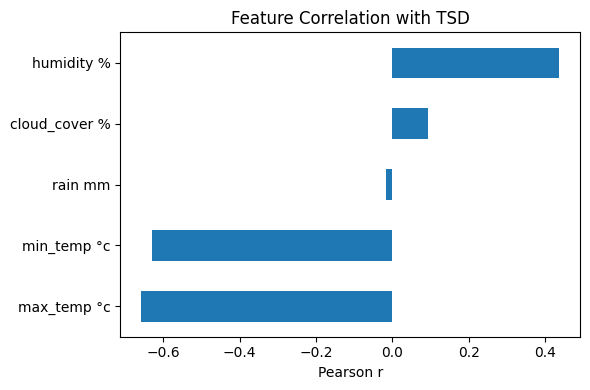

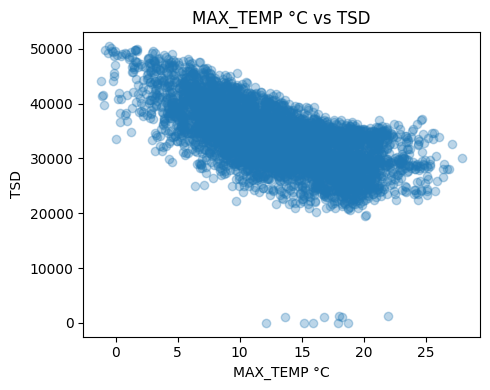

In [4]:
if "DATE" in cols_to_keep:
    cols_to_keep.remove("DATE")
corr_matrix = df[cols_to_keep].corr()

if 'TSD' in corr_matrix.columns:
    corr = corr_matrix['TSD'].drop('TSD')
    print("\nFeature vs. TSD correlation:\n", corr.sort_values(ascending=False))

    # Bar chart of correlations
    plt.figure(figsize=(6,4))
    corr.sort_values().plot.barh(title="Feature Correlation with TSD")
    plt.xlabel("Pearson r")
    plt.tight_layout()
    plt.show()

    # Scatter-plot the top driver
    best = corr.abs().idxmax()
    plt.figure(figsize=(5,4))
    plt.scatter(df[best], df['TSD'], alpha=0.3)
    plt.title(f"{best.upper()} vs TSD")
    plt.xlabel(best.upper())
    plt.ylabel("TSD")
    plt.tight_layout()
    plt.show()

In [11]:
# X = df['min_temp °c']
X = df[['max_temp °c']]  # Double brackets = DataFrame, not Series
y = df['TSD']
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,train_size=0.8,random_state=42)

In [ ]:


# # 🧹 Load and Clean Data
# df = pd.read_csv("merged_ukdata.csv")
# df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
# df.rename(columns={'date': 'DATE'}, inplace=True)

# # Remove wind columns
# wind_columns = [col for col in df.columns if 'WIND' in col.upper()]
# df.drop(columns=wind_columns, inplace=True)

# # Columns to keep
# expected_cols = ["min_temp °c", "max_temp °c", "rain mm", "humidity %", "cloud_cover %", "TSD", "DATE"]
# df.rename(columns=lambda col: col.upper() if col.lower() == "date" else col, inplace=True)
# cols_to_keep = [col for col in expected_cols if col in df.columns]
# df = df[cols_to_keep]

# # Null check
# print(df.isna().sum())
# df = df.dropna()

# 🚀 Feature Engineering
features = ['min_temp °c', 'max_temp °c', 'rain mm', 'humidity %', 'cloud_cover %']
# X = df[features]
# y = df['TSD']

# # 📈 Train/Test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🧪 Define Evaluation Function
def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print("R²:", r2_score(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("Median AE:", median_absolute_error(y_true, y_pred))

# 📉 Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model("Linear Regression", y_test, y_pred_lr)

# 🌳 Decision Tree
dtr = DecisionTreeRegressor(max_depth=4, random_state=0)
dtr.fit(X_train, y_train)
y_pred_dtr = dtr.predict(X_test)
evaluate_model("Decision Tree", y_test, y_pred_dtr)

# 🌲 Random Forest (Baseline)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model("Random Forest", y_test, y_pred_rf)

# 🔁 Cross-Validation on RF
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"\nRandom Forest Cross-Validated R²: {cv_scores.mean():.4f}")

# 🔍 Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("\nBest Hyperparameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

#  Evaluate Best Model
y_pred_best = best_rf.predict(X_test)
evaluate_model("Best RF (Grid Search)", y_test, y_pred_best)

# #  Feature Importances
# importances = best_rf.feature_importances_
# print("\n--- Feature Importances ---")
# for feat, imp in zip(features, importances):
#     print(f"{feat}: {imp:.4f}")

# Plot Feature Importances
# plt.figure(figsize=(6,4))
# sns.barplot(x=importances, y=features)
# plt.title("Feature Importances (Best RF)")
# plt.tight_layout()
# plt.show()



--- Linear Regression ---
R²: 0.45375356698214453
MSE: 17766810.755039785
RMSE: 4215.0694840108845
MAE: 3386.734484054498
Median AE: 3035.99108831599

--- Decision Tree ---
R²: 0.47267989833187984
MSE: 17151226.785877403
RMSE: 4141.403963135859
MAE: 3291.9362468105055
Median AE: 2913.7899936143003

--- Random Forest ---
R²: 0.22363482374499188
MSE: 25251484.18291815
RMSE: 5025.085490110407
MAE: 3960.7988792443107
Median AE: 3315.6712499999776

Random Forest Cross-Validated R²: -0.3114
Fitting 5 folds for each of 150 candidates, totalling 750 fits

Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 300}

--- Best RF (Grid Search) ---
R²: 0.44408041306147117
MSE: 18081432.663257092
RMSE: 4252.226788784565
MAE: 3374.1658816657286
Median AE: 3034.216781835392
